Columns:
 Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

Target Column: Heart Disease Status

Missing Values:
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               

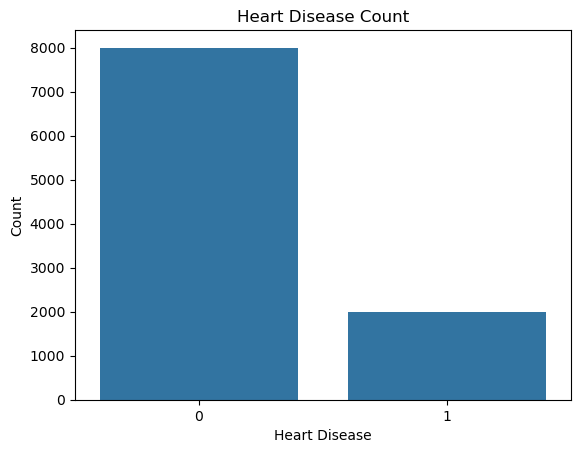


Number of Features: 20

Accuracy: 0.8

Confusion Matrix:
 [[1600    0]
 [ 400    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000


--- Test Prediction ---
Low chance of Heart Disease
Logistic Regression : 0.8
Decision Tree : 0.67
Random Forest : 0.8
SVM : 0.8


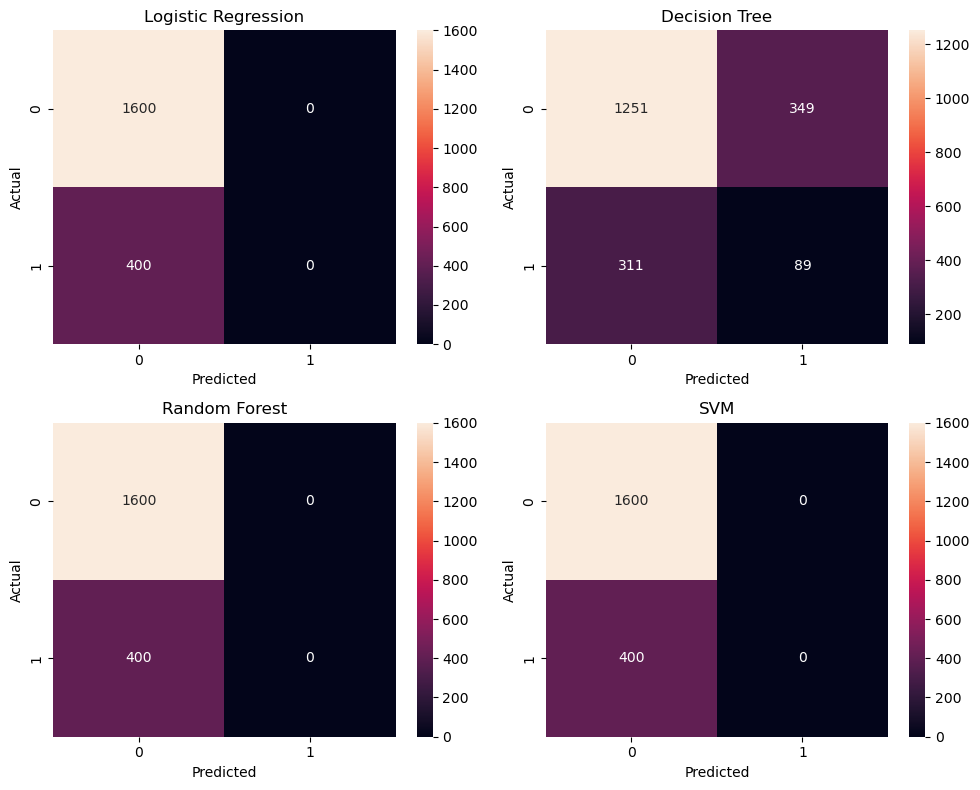

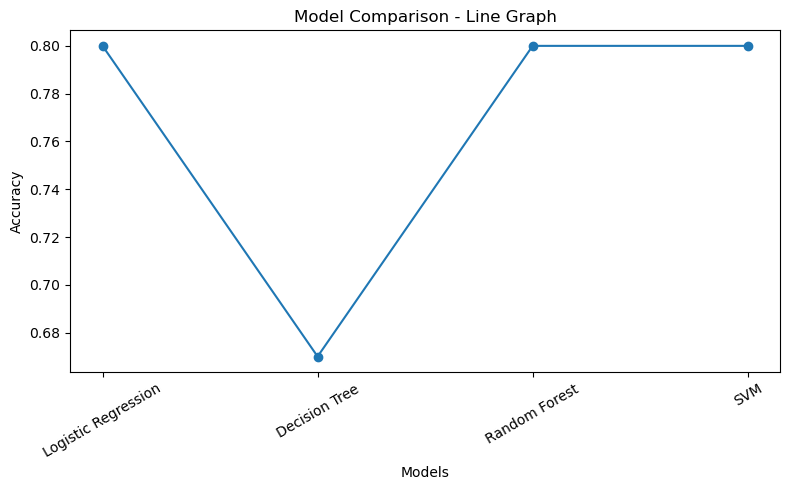

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

data = pd.read_csv("heart.csv")

print("Columns:\n", data.columns)

target_column = data.columns[-1]

print("\nTarget Column:", target_column)

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes

data = data.fillna(data.mean())

print("\nMissing Values:\n", data.isnull().sum())

plt.figure()
sns.countplot(x=target_column, data=data)
plt.title("Heart Disease Count")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

X = data.drop(target_column, axis=1)
y = data[target_column]

print("\nNumber of Features:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred, zero_division=0))

print("\n--- Test Prediction ---")

new_data = X.iloc[[0]]

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    print("High chance of Heart Disease")
else:
    print("Low chance of Heart Disease")

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

accuracies = {}
predictions = {}

for name, m in models.items():

    if name == "Logistic Regression" or name == "SVM":
        m.fit(X_train_scaled, y_train)
        y_pred_m = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        y_pred_m = m.predict(X_test)

    predictions[name] = y_pred_m
    accuracies[name] = accuracy_score(y_test, y_pred_m)

for name, accuracy in accuracies.items():
    print(name, ":", round(accuracy, 4))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.ravel()

for i, (name, pred) in enumerate(predictions.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

names = list(accuracies.keys())
values = list(accuracies.values())

plt.figure(figsize=(8, 5))

plt.plot(names, values, marker='o')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Line Graph")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

